In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
import joblib
import os

In [2]:
PROCESSED_DIR = "../dataset/processed"

if not os.path.exists(PROCESSED_DIR):
    raise FileNotFoundError(f"Directory {PROCESSED_DIR} not found. Please run preprocess_pipeline.ipynb first.")

print("Loading X data (Features)...")
X_train = pd.read_parquet(f"{PROCESSED_DIR}/X_train.parquet")
X_val = pd.read_parquet(f"{PROCESSED_DIR}/X_val.parquet")
X_test = pd.read_parquet(f"{PROCESSED_DIR}/X_test.parquet")

print("Loading y data (Labels)...")
y_train = pd.read_parquet(f"{PROCESSED_DIR}/y_train.parquet")['label']
y_val = pd.read_parquet(f"{PROCESSED_DIR}/y_val.parquet")['label']
y_test = pd.read_parquet(f"{PROCESSED_DIR}/y_test.parquet")['label']

print("\n--- Data Shapes ---")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

Loading X data (Features)...
Loading y data (Labels)...

--- Data Shapes ---
X_train: (432395, 162), y_train: (432395,)
X_val:   (54049, 162), y_val:   (54049,)
X_test:  (54050, 162), y_test:  (54050,)


In [3]:
print("Loading Preprocessing Artifacts...")

# Load Label Encoder
le = joblib.load(f"{PROCESSED_DIR}/label_encoder.joblib")
print("\nLabel mapping (class -> encoded):")
for cls in le.classes_:
    print(f"  {cls} -> {int(le.transform([cls])[0])}")

# Load Preprocessing Info (Zero variance cols and High correlation cols that were dropped)
preprocessing_info = joblib.load(f"{PROCESSED_DIR}/preprocessing_info.joblib")
print("\nPreprocessing Info:")
print(f"  Zero-variance columns dropped:     {len(preprocessing_info['zero_var_cols'])}")
print(f"  Highly-correlated columns dropped: {len(preprocessing_info['high_corr_cols'])}")
print(f"  Final feature columns count:       {len(preprocessing_info['feature_columns'])}")

Loading Preprocessing Artifacts...

Label mapping (class -> encoded):
  Attack -> 0
  Benign -> 1
  Suspicious -> 2

Preprocessing Info:
  Zero-variance columns dropped:     3
  Highly-correlated columns dropped: 152
  Final feature columns count:       162


## Modeling (Scaling + Linear SVM)

In [4]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

tune_svm_clf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "svm",
            SGDClassifier(
                loss="hinge",
                class_weight="balanced", # Explicitly handle imbalance
                max_iter=2000,
                random_state=42,
                n_jobs=-1
            ),
        ),
    ]
)

param_distributions = {
    "svm__alpha": loguniform(1e-5, 1e-1),
    "svm__penalty": ["l2", "l1"]
}

print("[SVM] Starting RandomizedSearchCV...")
search = RandomizedSearchCV(tune_svm_clf, param_distributions, n_iter=3, scoring='f1_macro', cv=3, random_state=42, n_jobs=1, verbose=2)
search.fit(X_train, y_train)

svm_clf = search.best_estimator_
print(f"[SVM] Best Hyperparameters: {search.best_params_}")

val_pred = svm_clf.predict(X_val)
print(f"[Val] Macro F1: {f1_score(y_val, val_pred, average='macro'):.4f}")

[SVM] Starting RandomizedSearchCV...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END .svm__alpha=0.00031489116479568613, svm__penalty=l2; total time=  13.1s
[CV] END .svm__alpha=0.00031489116479568613, svm__penalty=l2; total time=  13.5s
[CV] END .svm__alpha=0.00031489116479568613, svm__penalty=l2; total time=  11.2s
[CV] END .svm__alpha=5.4167545832474595e-05, svm__penalty=l1; total time= 2.3min
[CV] END .svm__alpha=5.4167545832474595e-05, svm__penalty=l1; total time=  48.1s
[CV] END .svm__alpha=5.4167545832474595e-05, svm__penalty=l1; total time= 2.0min
[CV] END ..svm__alpha=0.0024810409748678114, svm__penalty=l2; total time=   7.2s
[CV] END ..svm__alpha=0.0024810409748678114, svm__penalty=l2; total time=   7.5s
[CV] END ..svm__alpha=0.0024810409748678114, svm__penalty=l2; total time=   7.1s
[SVM] Best Hyperparameters: {'svm__alpha': np.float64(0.00031489116479568613), 'svm__penalty': 'l2'}
[Val] Macro F1: 0.6932


## Evaluation

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# Predict class labels
val_pred = svm_clf.predict(X_val)

# Decision scores for ROC‑AUC (works for multi‑class)
val_scores = svm_clf.decision_function(X_val)

# Classification metrics (weighted average for 3 classes)
accuracy = accuracy_score(y_val, val_pred)
precision = precision_score(y_val, val_pred, average='weighted')
recall = recall_score(y_val, val_pred, average='weighted')
f1 = f1_score(y_val, val_pred, average='weighted')

print("--- Classification Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

--- Classification Metrics ---
Accuracy:  0.8997
Precision: 0.9050
Recall:    0.8997
F1-score:  0.8981


In [6]:
from sklearn.preprocessing import label_binarize
val_scores = svm_clf.decision_function(X_val)
n_classes = len(svm_clf.classes_)
y_val_bin = label_binarize(y_val, classes=range(n_classes))

auc_per_class = []
for i in range(n_classes):
    auc_i = roc_auc_score(y_val_bin[:, i], val_scores[:, i])
    auc_per_class.append(auc_i)

roc_auc_macro = sum(auc_per_class) / n_classes

print("\n--- ROC-AUC (macro, from decision function) ---")
for i, auc_val in enumerate(auc_per_class):
    print(f"  Class {i}: {auc_val:.4f}")
print(f"  Macro average: {roc_auc_macro:.4f}")


--- ROC-AUC (macro, from decision function) ---
  Class 0: 0.9442
  Class 1: 0.9522
  Class 2: 0.8633
  Macro average: 0.9199


In [7]:
print("[SVM] Predicting on test set...")
y_pred_encoded = svm_clf.predict(X_test)

y_pred_labels = le.inverse_transform(y_pred_encoded)
y_test_labels = le.inverse_transform(y_test)

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test_labels, y_pred_labels, digits=4))

macro_f1 = f1_score(y_test_labels, y_pred_labels, average="macro")
weighted_f1 = f1_score(y_test_labels, y_pred_labels, average="weighted")
print("KEY METRICS:")
print(f"  Macro F1:    {macro_f1:.4f}  ← Primary")
print(f"  Weighted F1: {weighted_f1:.4f}  ← Secondary")

[SVM] Predicting on test set...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Attack     0.9811    0.7908    0.8757     17044
      Benign     0.9060    0.9896    0.9459     34918
  Suspicious     0.2592    0.2696    0.2643      2088

    accuracy                         0.8991     54050
   macro avg     0.7154    0.6833    0.6953     54050
weighted avg     0.9047    0.8991    0.8975     54050

KEY METRICS:
  Macro F1:    0.6953  ← Primary
  Weighted F1: 0.8975  ← Secondary


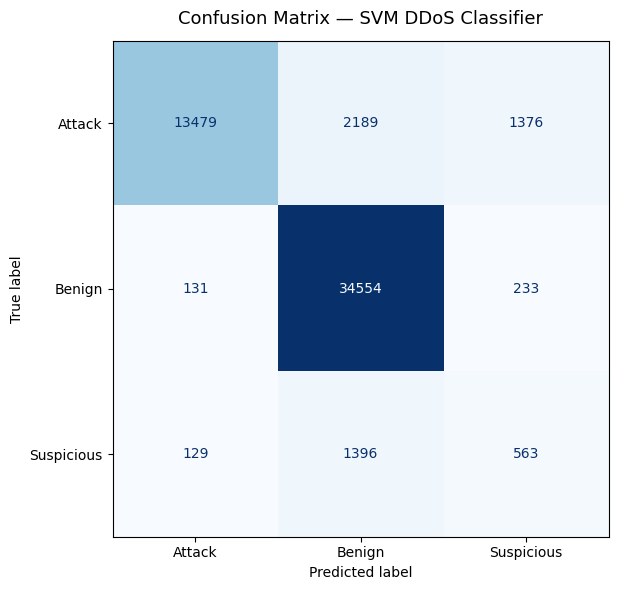

[Output] Confusion matrix saved → svm_confusion_matrix.png


In [8]:
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — SVM DDoS Classifier", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("svm_confusion_matrix.png", dpi=150)
plt.show()
print("[Output] Confusion matrix saved → svm_confusion_matrix.png")

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

try:
    y_true_for_metrics = y_test_labels
    y_pred_for_metrics = y_pred_labels
except NameError:
    y_true_for_metrics = y_test
    if 'y_pred_encoded' in locals():
        y_pred_for_metrics = y_pred_encoded
    elif 'y_pred' in locals():
        y_pred_for_metrics = y_pred

accuracy = accuracy_score(y_true_for_metrics, y_pred_for_metrics)
precision = precision_score(y_true_for_metrics, y_pred_for_metrics, average='weighted')
recall = recall_score(y_true_for_metrics, y_pred_for_metrics, average='weighted')
f1 = f1_score(y_true_for_metrics, y_pred_for_metrics, average='weighted')

try:
    if hasattr(svm_clf, 'predict_proba'):
        y_pred_proba = svm_clf.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
        roc_auc_str = f"{roc_auc:.4f}"
    else:
        # Some models like LinearSVC don't have predict_proba but might have decision_function
        if hasattr(svm_clf, 'decision_function'):
            y_pred_decision = svm_clf.decision_function(X_test)
            n_classes = len(svm_clf.classes_)
            
            # Binarize labels for multi-class ROC-AUC using decision functions
            y_test_bin = label_binarize(y_test, classes=range(n_classes))
            
            roc_auc_weighted = 0
            total_samples = len(y_test)
            for i in range(n_classes):
                auc_i = roc_auc_score(y_test_bin[:, i], y_pred_decision[:, i])
                weight_i = sum(y_test_bin[:, i]) / total_samples
                roc_auc_weighted += auc_i * weight_i
                
            roc_auc_str = f"{roc_auc_weighted:.4f} (weighted)"
        else:
            roc_auc_str = "N/A (predict_proba not available)"
except Exception as e:
    roc_auc_str = f"N/A ({e})"

print("--- Classification Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}\n")
print("--- ROC-AUC ---")
print(f"ROC-AUC Score: {roc_auc_str}")

--- Classification Metrics ---
Accuracy:  0.8991
Precision: 0.9047
Recall:    0.8991
F1-score:  0.8975

--- ROC-AUC ---
ROC-AUC Score: 0.9453 (weighted)
